# Category Intelligence — Retail Product Performance EDA

**Calibo AI Academy**
**Phase 1 — Mini Use Case 01**
**Industry:** Retail / E-commerce

**Author:** Varshitha
**Tools used:** Python, Pandas, NumPy, Matplotlib, Seaborn, Jupyter Notebook

---

This notebook analyzes six months (January–June 2026) of retail transaction data across five product
categories — Electronics, Apparel, Grocery, Home & Kitchen, and Personal Care — to generate a data-driven
briefing for a **Category Manager** ahead of a **quarterly supplier review**.


## CBIM Problem Canvas

**1. Situation (S)**
The retail chain sells products across five categories (Electronics, Apparel, Grocery, Home & Kitchen,
Personal Care) through multiple stores. Six months of transaction-level sales data (Jan–Jun 2026) is
available, capturing revenue, units sold, unit price, and discount percentage for every transaction.

**2. Complication (C)**
The Category Manager must walk into a quarterly supplier review with a clear view of which categories
and products are growing, which are declining, and whether ongoing discounting is actually working —
but this view does not currently exist in a structured, evidence-based form.

**3. Question (Q)**
Which categories and products deserve increased supplier investment, which should be challenged in the
supplier review, and is the current discounting strategy generating a meaningful revenue return?

**4. SSOT (Single Source of Truth)**
`MUC01_Retail_Sales_Dataset.csv` — transaction-level retail sales records (Jan 1, 2026 – Jun 30, 2026),
containing `transaction_id`, `date`, `store_id`, `store_city`, `category`, `product_name`, `units_sold`,
`unit_price`, `revenue`, and `discount_pct`.

**5. Success Definition**
A clear, numbers-backed summary of category and product performance trends, a discount-effectiveness
verdict, and day-of-week / monthly demand patterns — packaged into a briefing the Category Manager can
use directly in the supplier review.

**6. Primary Stakeholder**
The **Category Manager**, preparing for a quarterly supplier review.


## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


## Load and Inspect Data

The dataset is loaded from a relative path so this notebook runs on any machine as long as
`MUC01_Retail_Sales_Dataset.csv` sits in the same project folder.

In [2]:
df = pd.read_csv("MUC01_Retail_Sales_Dataset.csv")
df.head()


**What this shows:** each row is a single product-line transaction — one store, one product,
one day — with the units sold, unit price, resulting revenue, and any discount applied.

In [3]:
print("Shape (rows, columns):", df.shape)


Shape (rows, columns): (107836, 10)


**Business read:** the dataset contains just under 108,000 individual sales transactions across
six months — enough volume to draw reliable category- and product-level conclusions.

In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 107836 entries, 0 to 107835
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   transaction_id  107836 non-null  str    
 1   date            107836 non-null  str    
 2   store_id        107836 non-null  str    
 3   store_city      107836 non-null  str    
 4   category        107836 non-null  str    
 5   product_name    107836 non-null  str    
 6   units_sold      107836 non-null  int64  
 7   unit_price      107836 non-null  float64
 8   revenue         107836 non-null  float64
 9   discount_pct    107836 non-null  int64  
dtypes: float64(2), int64(2), str(6)
memory usage: 8.2 MB


In [5]:
df.dtypes


**Data quality check:** `date` currently loads as text, not a true date — this needs to be
converted before any time-based analysis (monthly trend, day-of-week pattern) will work correctly.

In [6]:
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
transaction_id    0
date              0
store_id          0
store_city        0
category          0
product_name      0
units_sold        0
unit_price        0
revenue           0
discount_pct      0
dtype: int64


**Business read:** there are no missing values in any column — the dataset is complete and usable as-is.

In [7]:
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 0


**Business read:** there are no duplicate transactions, so revenue totals will not be inflated by double-counted rows.

In [8]:
df.describe()


**Business read:** unit prices and discount levels span a wide but sensible range, and there are
no negative revenue or negative unit values — an early sign the data does not contain obvious entry errors.

In [9]:
print("Unique products:", df["product_name"].nunique())
print("Unique categories:", df["category"].nunique())
print("Categories:", sorted(df["category"].unique()))


Unique products: 25
Unique categories: 5
Categories: ['Apparel', 'Electronics', 'Grocery', 'Home & Kitchen', 'Personal Care']


**Business read:** the data covers the expected 5 categories, each with 5 distinct products
(25 products total) — matching the structure the Category Manager works with.

In [10]:
df["date"] = pd.to_datetime(df["date"])
print("Date range:", df["date"].min().date(), "to", df["date"].max().date())
print("date column dtype after conversion:", df["date"].dtype)


Date range: 2026-01-01 to 2026-06-30
date column dtype after conversion: datetime64[us]


**Data quality note:** `date` is now a proper datetime column, confirmed to span the full Jan 1 – Jun 30, 2026 window described in the project brief.

## Category Revenue Trend

We look at how monthly revenue for each of the five categories has moved over the six-month window.

In [11]:
df["month"] = df["date"].dt.to_period("M").astype(str)

cat_month_revenue = (
    df.groupby(["month", "category"])["revenue"]
    .sum()
    .reset_index()
    .pivot(index="month", columns="category", values="revenue")
)
cat_month_revenue


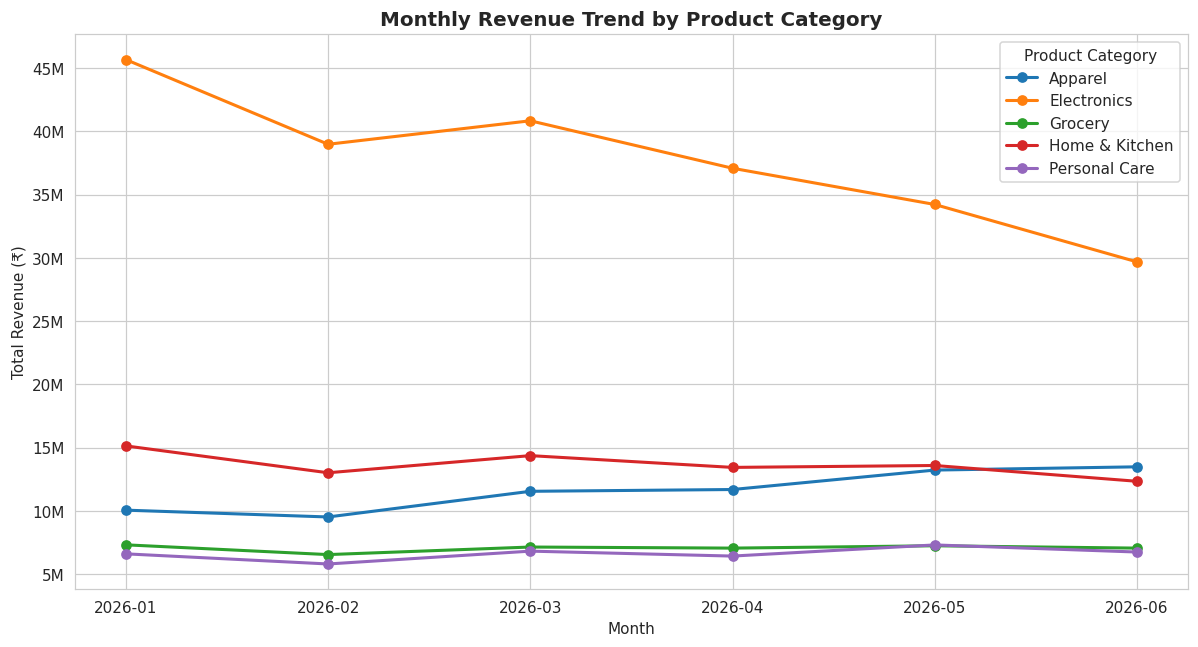

In [12]:
fig, ax = plt.subplots(figsize=(11, 6))
for category in cat_month_revenue.columns:
    ax.plot(cat_month_revenue.index, cat_month_revenue[category], marker="o", linewidth=2, label=category)

ax.set_title("Monthly Revenue Trend by Product Category")
ax.set_xlabel("Month")
ax.set_ylabel("Total Revenue (\u20b9)")
ax.legend(title="Product Category", loc="upper right")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M"))
plt.tight_layout()
plt.show()


In [13]:
first_month = cat_month_revenue.iloc[0]
last_month = cat_month_revenue.iloc[-1]
pct_change = ((last_month - first_month) / first_month * 100).sort_values()

cv = (cat_month_revenue.std() / cat_month_revenue.mean()).sort_values()

total_revenue_by_category = df.groupby("category")["revenue"].sum().sort_values(ascending=False)

print("Percent change in monthly revenue, Jan -> Jun 2026 (most negative = biggest decline):")
print(pct_change.round(1))
print()
print("Coefficient of variation across the 6 months (lower = more consistent):")
print(cv.round(3))
print()
print("Total 6-month revenue by category (overall scale):")
print(total_revenue_by_category.round(0))

declined_most = pct_change.idxmin()
most_consistent = cv.idxmin()
strongest_growth = pct_change.idxmax()
print()
print(f"Declined the most: {declined_most} ({pct_change[declined_most]:.1f}%)")
print(f"Most consistent: {most_consistent} (CV = {cv[most_consistent]:.3f})")
print(f"Strongest growth: {strongest_growth} ({pct_change[strongest_growth]:.1f}%)")


Percent change in monthly revenue, Jan -> Jun 2026 (most negative = biggest decline):
category
Electronics      -35.00
Home & Kitchen   -18.50
Grocery           -3.50
Personal Care      2.20
Apparel           34.10
dtype: float64

Coefficient of variation across the 6 months (lower = more consistent):
category
Grocery          0.04
Home & Kitchen   0.07
Personal Care    0.07
Apparel          0.14
Electronics      0.15
dtype: float64

Total 6-month revenue by category (overall scale):
category
Electronics      226,527,725.00
Home & Kitchen    81,845,721.00
Apparel           69,479,590.00
Grocery           42,302,581.00
Personal Care     39,648,560.00
Name: revenue, dtype: float64

Declined the most: Electronics (-35.0%)
Most consistent: Grocery (CV = 0.039)
Strongest growth: Apparel (34.1%)


### Business Interpretation

**Electronics fell the most** — its monthly revenue dropped by about **35%** from January to June 2026,
and it is also the least consistent of the five categories month-to-month. This matters a great deal
because Electronics is still by far the *largest* category by total revenue, so a sustained 35% decline
represents a large absolute loss for the business, not a rounding error. **Grocery is the most consistent**
category (the smallest coefficient of variation), which is expected for a staple, low-discretionary
category, and makes it a dependable but low-growth baseline. **Apparel shows the strongest growth**,
gaining roughly 34% over the same period — this is the category building momentum. For the supplier
review, the Category Manager should treat the Electronics decline as the headline issue to interrogate
with suppliers, while pointing to Apparel's growth as the category worth pushing for more supplier
investment and shelf space.

## Top and Bottom Products by Category

For every category, we rank products by total 6-month revenue and identify the top 2 and bottom 2 performers.

In [14]:
rows = []
for category in sorted(df["category"].unique()):
    prod_rev = (
        df[df["category"] == category]
        .groupby("product_name")["revenue"]
        .sum()
        .sort_values(ascending=False)
    )
    top2 = prod_rev.head(2)
    bottom2 = prod_rev.tail(2)
    for product, revenue in top2.items():
        rows.append({"Category": category, "Rank Type": "Top", "Product": product, "Total Revenue": revenue})
    for product, revenue in bottom2.items():
        rows.append({"Category": category, "Rank Type": "Bottom", "Product": product, "Total Revenue": revenue})

top_bottom_summary = pd.DataFrame(rows)
top_bottom_summary


In [15]:
weakest_products = top_bottom_summary[top_bottom_summary["Rank Type"] == "Bottom"].sort_values("Total Revenue")
print("Lowest-revenue products overall (across all categories):")
print(weakest_products.head(5).to_string(index=False))


Lowest-revenue products overall (across all categories):
     Category Rank Type     Product  Total Revenue
Personal Care    Bottom   Sunscreen   7,593,863.45
Personal Care    Bottom  Toothpaste   7,768,812.48
      Grocery    Bottom Sugar (1kg)   8,377,786.05
      Grocery    Bottom    Oil (1L)   8,431,630.01
      Apparel    Bottom       Kurta  13,606,747.03


### Business Interpretation

Within every category, revenue is fairly evenly spread across its five products — there is no single
product collapsing on its own inside a category. That means the **Electronics decline is a category-wide
problem, not a single weak SKU**: Smart TV and Tablet are the softest performers inside Electronics, but
all five Electronics products contribute to the drop, and none of them individually explains a 35% fall.
This is the product/category combination that deserves the most challenge in the supplier review —
suppliers for the Electronics line as a whole should be asked what is driving softer demand (pricing,
newer competing models, stockouts, etc.), rather than singling out one product.

## Discount Effectiveness

We group transactions into discount brackets and compare average revenue per transaction and average
units sold across brackets, using the actual `discount_pct` values present in the data.

In [16]:
print("Distinct discount_pct values in the data:", sorted(df["discount_pct"].unique()))


Distinct discount_pct values in the data: [np.int64(0), np.int64(5), np.int64(10), np.int64(15), np.int64(20)]


In [17]:
bracket_edges = [-1, 0, 5, 10, 15, 20, 100]
bracket_labels = ["0%", "5%", "10%", "15%", "20%", "25%+"]
df["discount_bracket"] = pd.cut(df["discount_pct"], bins=bracket_edges, labels=bracket_labels)

discount_summary = df.groupby("discount_bracket", observed=False).agg(
    num_transactions=("transaction_id", "count"),
    avg_revenue_per_transaction=("revenue", "mean"),
    avg_units_sold=("units_sold", "mean"),
)
discount_summary


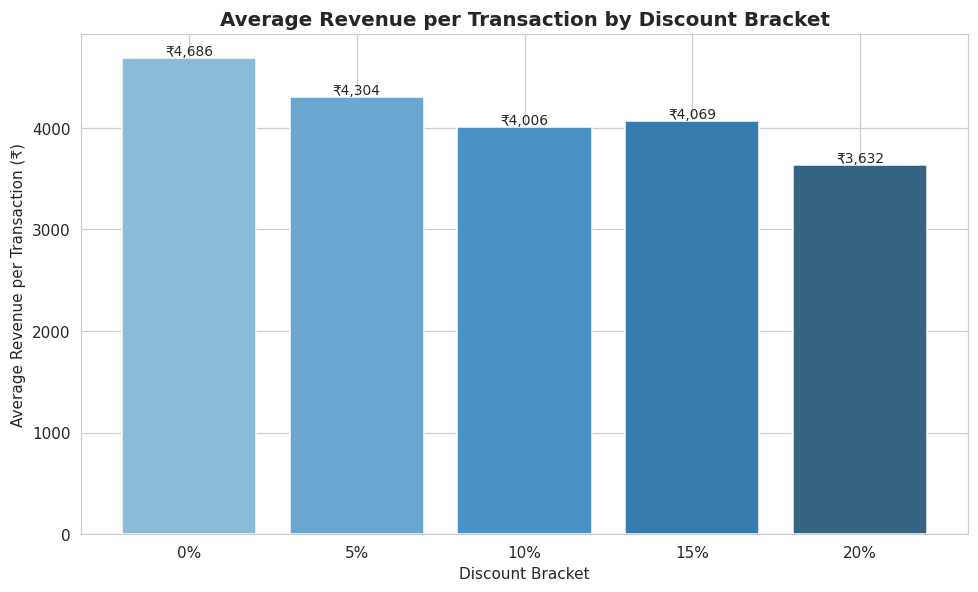

In [18]:
fig, ax = plt.subplots(figsize=(9, 5.5))
colors = sns.color_palette("Blues_d", n_colors=len(discount_summary))
bars = ax.bar(discount_summary.index.astype(str), discount_summary["avg_revenue_per_transaction"], color=colors)

ax.set_title("Average Revenue per Transaction by Discount Bracket")
ax.set_xlabel("Discount Bracket")
ax.set_ylabel("Average Revenue per Transaction (\u20b9)")
for bar in bars:
    height = bar.get_height()
    if not np.isnan(height):
        ax.annotate(f"\u20b9{height:,.0f}", (bar.get_x() + bar.get_width()/2, height),
                    ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()


In [19]:
valid = discount_summary.dropna()
best_bracket = valid["avg_revenue_per_transaction"].idxmax()
worst_bracket = valid["avg_revenue_per_transaction"].idxmin()
zero_disc = valid.loc["0%", "avg_revenue_per_transaction"]
top_disc_bracket = valid.index[-1]
top_disc_value = valid.loc[top_disc_bracket, "avg_revenue_per_transaction"]

print(f"Highest avg revenue/txn: {best_bracket} bracket (\u20b9{valid['avg_revenue_per_transaction'].max():,.0f})")
print(f"Lowest avg revenue/txn: {worst_bracket} bracket (\u20b9{valid['avg_revenue_per_transaction'].min():,.0f})")
print(f"0% discount avg revenue/txn: \u20b9{zero_disc:,.0f}")
print(f"Highest discount bracket present ({top_disc_bracket}) avg revenue/txn: \u20b9{top_disc_value:,.0f}")
print(f"Change vs 0% bracket: {(top_disc_value - zero_disc)/zero_disc*100:.1f}%")
print()
print("Note: no transactions in the data carry a discount of 25% or higher, so the '25%+' bracket is empty.")


Highest avg revenue/txn: 0% bracket (₹4,686)
Lowest avg revenue/txn: 20% bracket (₹3,632)
0% discount avg revenue/txn: ₹4,686
Highest discount bracket present (20%) avg revenue/txn: ₹3,632
Change vs 0% bracket: -22.5%

Note: no transactions in the data carry a discount of 25% or higher, so the '25%+' bracket is empty.


### Business Interpretation

The pattern runs in the **opposite direction** of what a "discounts drive bigger baskets" story would
predict. Average revenue per transaction is highest with **no discount at all (0%)**, at roughly ₹4,686,
and it steadily *decreases* as the discount level rises, down to roughly ₹3,632 at the 20% bracket —
about a 22% drop. Average units sold per transaction, meanwhile, stays essentially flat across every
bracket (all close to ~2.6 units). In other words, **deeper discounts are not pulling in bigger baskets
or more items per transaction** — they mainly reduce the revenue collected on each transaction, since
revenue = units × price × (1 − discount) and units aren't rising to compensate.

Because the dataset does not include product cost or margin data, this analysis **cannot measure margin
erosion as a fact** — only revenue per transaction, which is what's stated here. But on revenue alone,
the current discounting pattern does not show a proportionate return: transactions are not getting
meaningfully larger as discounts increase, so revenue is being given up without a matching volume payoff.
This is a specific, numbers-backed point the Category Manager can raise with suppliers whose promotional
plans rely on deep discounting.

## Day-of-Week and Monthly Patterns

In [20]:
df["day_of_week"] = df["date"].dt.day_name()
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

avg_daily_revenue_by_weekday = (
    df.groupby("day_of_week")["revenue"].mean().reindex(weekday_order)
)
avg_daily_revenue_by_weekday


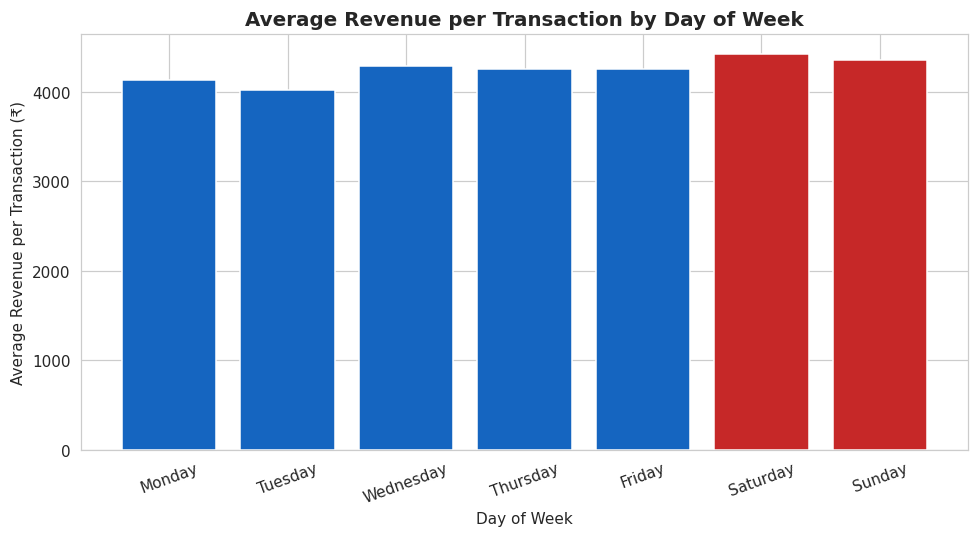

In [21]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#c62828" if day in ("Saturday", "Sunday") else "#1565c0" for day in weekday_order]
ax.bar(weekday_order, avg_daily_revenue_by_weekday.values, color=colors)
ax.set_title("Average Revenue per Transaction by Day of Week")
ax.set_xlabel("Day of Week")
ax.set_ylabel("Average Revenue per Transaction (\u20b9)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


In [22]:
monthly_total_revenue = df.groupby("month")["revenue"].sum()
monthly_total_revenue


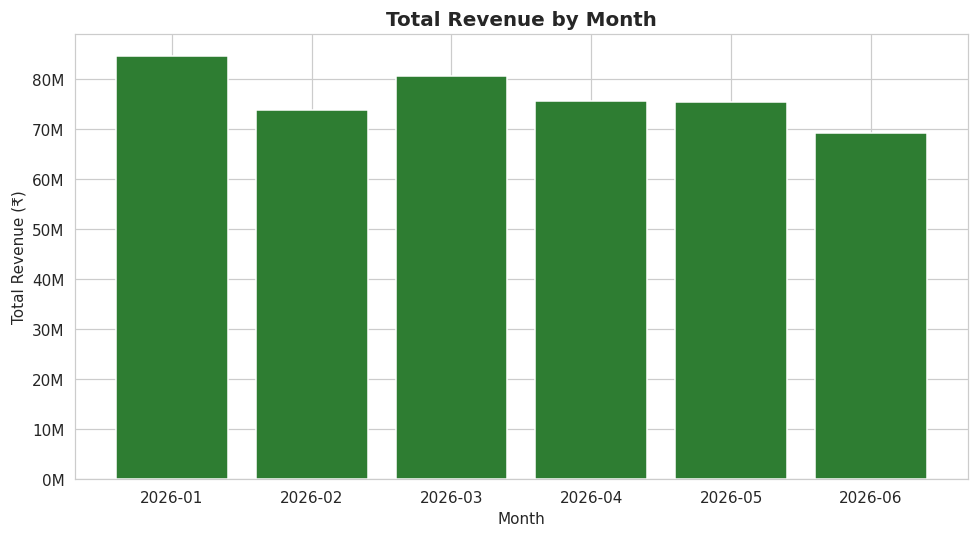

In [23]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(monthly_total_revenue.index, monthly_total_revenue.values, color="#2e7d32")
ax.set_title("Total Revenue by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Total Revenue (\u20b9)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M"))
plt.tight_layout()
plt.show()


In [24]:
best_day = avg_daily_revenue_by_weekday.idxmax()
worst_day = avg_daily_revenue_by_weekday.idxmin()
best_month = monthly_total_revenue.idxmax()
worst_month = monthly_total_revenue.idxmin()

print(f"Best day (avg revenue/transaction): {best_day} (\u20b9{avg_daily_revenue_by_weekday.max():,.0f})")
print(f"Worst day (avg revenue/transaction): {worst_day} (\u20b9{avg_daily_revenue_by_weekday.min():,.0f})")
print(f"Best month (total revenue): {best_month} (\u20b9{monthly_total_revenue.max():,.0f})")
print(f"Worst month (total revenue): {worst_month} (\u20b9{monthly_total_revenue.min():,.0f})")


Best day (avg revenue/transaction): Saturday (₹4,420)
Worst day (avg revenue/transaction): Tuesday (₹4,018)
Best month (total revenue): 2026-01 (₹84,768,131)
Worst month (total revenue): 2026-06 (₹69,282,134)


In [25]:
electronics_share_by_month = (
    df[df["category"] == "Electronics"].groupby("month")["revenue"].sum() / monthly_total_revenue * 100
)
print("Electronics share of total monthly revenue:")
print(electronics_share_by_month.round(1))


Electronics share of total monthly revenue:
month
2026-01   53.90
2026-02   52.80
2026-03   50.60
2026-04   49.00
2026-05   45.30
2026-06   42.80
Name: revenue, dtype: float64


### Business Interpretation

**Saturday and Sunday are the strongest days**, both in total weekend revenue and in average revenue per
transaction, while **Tuesday is consistently the weakest**. This is a normal retail weekly pattern and
suggests promotional pushes and supplier-funded campaigns are best timed to launch just before the
weekend so they ride the natural traffic peak, rather than mid-week when baseline demand is lower.

At the monthly level, **January was the strongest month and June the weakest**, and total revenue has
declined in most months since January. The category most responsible for this overall slide is
**Electronics**: its share of total monthly revenue fell steadily from about 54% in January to under
43% by June, meaning Electronics is not just declining in isolation — it is dragging down the entire
chain's month-over-month total. This reinforces Electronics as the category to prioritize in the
supplier review, and ties directly back to the revenue-trend finding in Section 5.

## Category Manager Briefing

**Apparel has the strongest case for increased supplier investment**: it grew roughly 34% in monthly
revenue from January to June 2026, the only category to show sustained growth over the period, making it
the clear candidate for expanded shelf space and supplier commitments. **Electronics should be challenged
in the supplier review**: its monthly revenue fell approximately 35%, from about ₹45.7 million in January
to about ₹29.7 million in June, and its declining share of total chain revenue (54% down to 43%) shows it
is dragging the whole business's monthly total down with it — Smart TV and Tablet are its softest products
and are a reasonable starting point for supplier questions. On discounting, the data shows a clear finding:
**average revenue per transaction falls as discount depth increases** (from about ₹4,686 at 0% discount to
about ₹3,632 at the 20% bracket) while average units per transaction stay essentially flat — discounts are
not generating larger baskets. Before finalizing any recommendation, the Category Manager should obtain
**product cost / margin data**, since this dataset contains revenue only — without it, the true profitability
impact of the Electronics decline and of the discounting pattern cannot be assessed, only their effect on
top-line revenue.

## Key Findings

**Key Finding 1: Electronics revenue is declining sharply**
- Supporting number: monthly revenue fell ~35% from January (₹45.7M) to June (₹29.7M) 2026, and Electronics'
  share of total chain revenue dropped from 54% to 43% over the same period.
- Business implication: Electronics is the single biggest driver of the chain's overall revenue slowdown
  and is the top item to raise with suppliers in the review.

**Key Finding 2: Apparel is the standout growth category**
- Supporting number: Apparel monthly revenue grew ~34% from January to June 2026, the only category with
  sustained growth across the period.
- Business implication: Apparel is the strongest candidate for increased supplier investment and shelf space.

**Key Finding 3: Deeper discounts are not generating bigger transactions**
- Supporting number: average revenue per transaction drops from ~₹4,686 at 0% discount to ~₹3,632 at the
  20% discount bracket, while average units sold per transaction stays flat (~2.6 units) across all brackets.
- Business implication: the current discount strategy is giving up revenue per transaction without a
  matching increase in basket size — worth revisiting with suppliers who fund promotional discounting.


## Limitations

- **No cost or margin data:** the dataset contains revenue, price, and discount fields, but no product
  cost. This means profitability and true margin impact — including of the discount pattern in Section 7 —
  cannot be measured directly, only inferred from revenue trends.
- **Six-month window only:** the analysis covers January–June 2026. Seasonal effects beyond this window
  (e.g. festive-season demand, year-end retail patterns) cannot be observed or ruled out.
- **Store-level detail not explored:** `store_id` and `store_city` are available in the data but were not
  analyzed here; regional or store-level variation in the trends above is a natural next step.
- **Simulated/academic dataset:** this notebook is built for the Calibo AI Academy Phase 1 Mini Use Case
  and the dataset should be treated as representative training data rather than live production figures.
